In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
import glob
from sklearn.model_selection import RandomizedSearchCV

In [14]:
# Load dataset
files = glob.glob("Dataset/*.csv")
df_list = [pd.read_csv(file) for file in files]

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

print(df.columns.tolist())

df.columns = df.columns.str.strip()

print(df["Label"].value_counts())

(2830743, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count

In [15]:
# Encode labels: BENIGN=0, Attack=1
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

# Features
features = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "FIN Flag Count",
    "ACK Flag Count"
]

# clean data
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [16]:
X = df[features]
y = df["Label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
# Initialize XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Cross-validation with recall
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_clf, X, y, cv=cv, scoring="recall")
print("Mean recall:", scores.mean())

c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:26:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:26:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:26:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:27:03] WARNING: C:\actio

Mean recall: 0.9896632139247211


In [18]:
# Train model
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)

# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:27:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[453192   1073]
 [  1137 110174]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       0.99      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      0.99      0.99    565576
weighted avg       1.00      1.00      1.00    565576



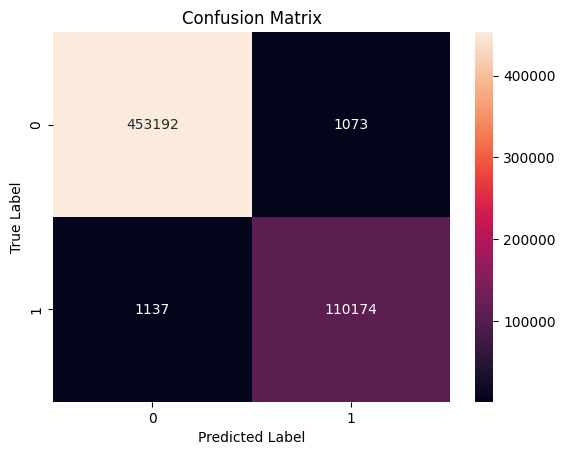

In [19]:
# Confusion matrix heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

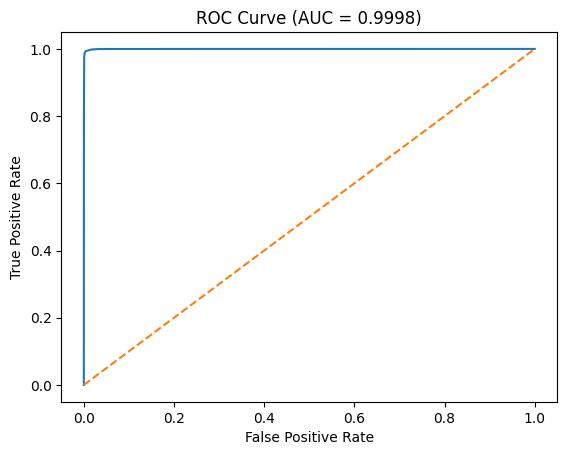

In [20]:
# ROC curve
y_probs = xgb_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

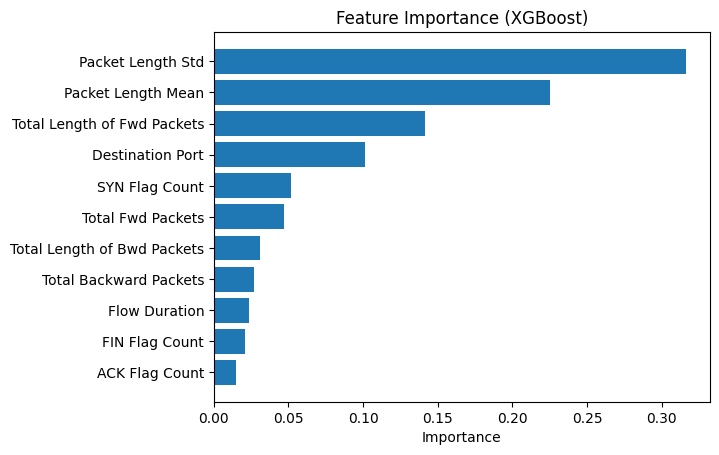

In [21]:
# Feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_clf.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (XGBoost)")
plt.show()


In [22]:
# Save model
joblib.dump(xgb_clf, "xgb_model.pkl")

['xgb_model.pkl']

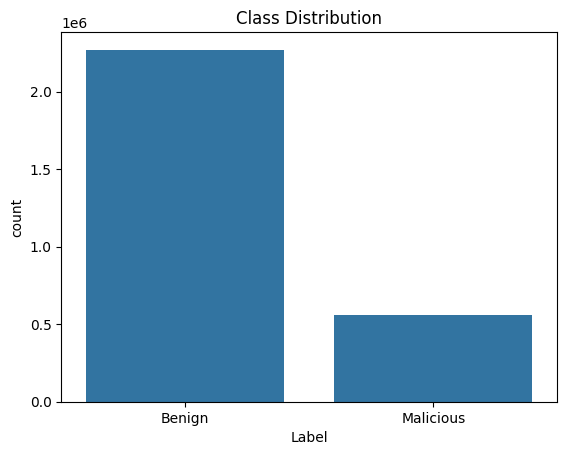

In [23]:
# Class distribution
plt.figure()
sns.countplot(x=y)
plt.xticks([0,1], ["Benign", "Malicious"])
plt.title("Class Distribution")
plt.show()

In [24]:
# Print ROC AUC
print("ROC AUC:", roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]))

ROC AUC: 0.9997562976228044


In [25]:
# HYPERPARAMETER TUNING 

# Base model
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter space
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 3, 5]
}

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search (optimize recall!)
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=25,  # increase to 50+ if you want better tuning
    scoring="recall",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit tuner
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Recall:", random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 1.0}
Best Recall: 0.9908365057440285


In [26]:
# Best model
best_xgb = random_search.best_estimator_

# Train best model
best_xgb.fit(X_train, y_train)

# Predictions
y_pred = best_xgb.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

c:\Users\izzyd\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[453420    845]
 [   990 110321]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       0.99      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       1.00      0.99      0.99    565576
weighted avg       1.00      1.00      1.00    565576



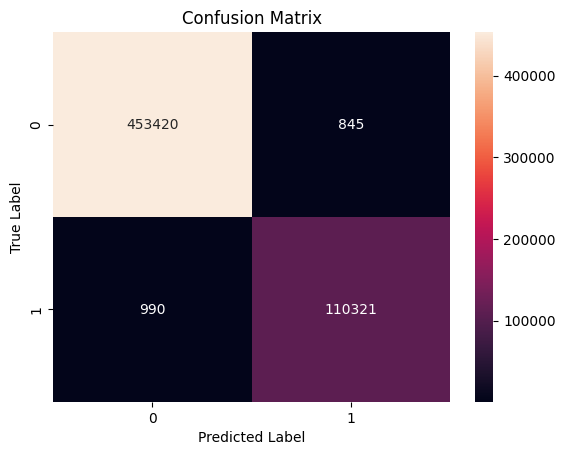

In [27]:
# Confusion matrix plot
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

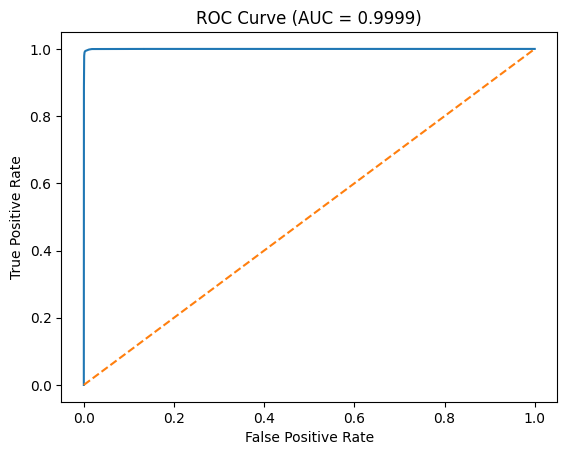

In [28]:
# ROC Curve
y_probs = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

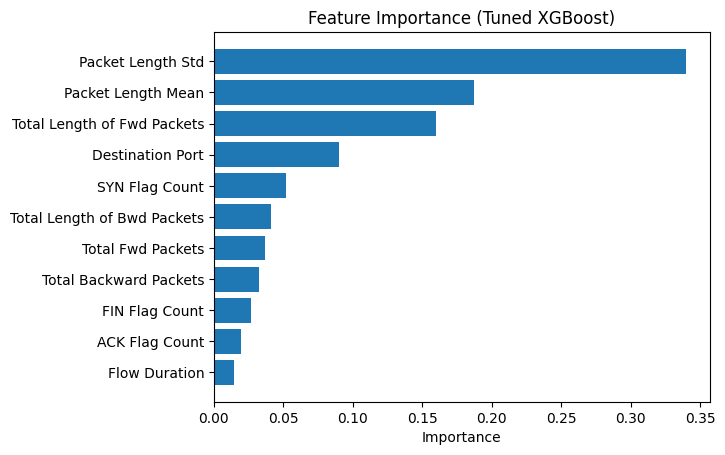

In [29]:
# Feature importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Tuned XGBoost)")
plt.show()

In [30]:
# Save model
joblib.dump(best_xgb, "xgb_tuned_model.pkl")

['xgb_tuned_model.pkl']

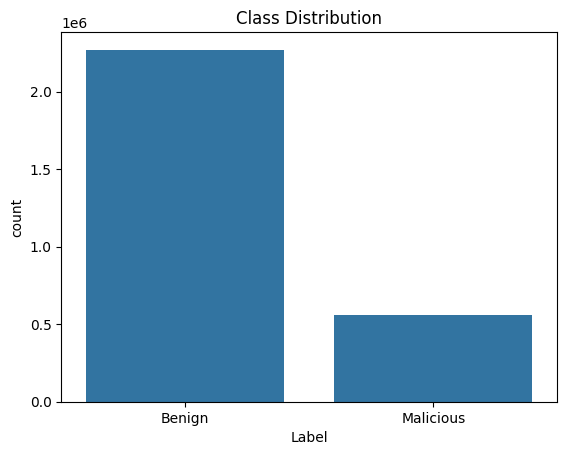

In [31]:
# Class distribution
plt.figure()
sns.countplot(x=y)
plt.xticks([0,1], ["Benign", "Malicious"])
plt.title("Class Distribution")
plt.show()

In [32]:
# Final ROC AUC
print("ROC AUC:", roc_auc)

ROC AUC: 0.9998559636715623
